# Лекция 7. Физические атаки в реальном мире

Демонстрация: adversarial patch, устойчивый к трансформациям (упрощённая EoT), тест на повороте/шуме.

## 1. Обучение базовой модели

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)
np.random.seed(0)

import torchvision
import torchvision.transforms as T

transform = T.Compose([T.ToTensor()])
train_ds = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=1, shuffle=True)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.fc = nn.Linear(32*7*7,10)
    def forward(self,x):
        x = F.relu(self.conv1(x)); x = F.max_pool2d(x,2)
        x = F.relu(self.conv2(x)); x = F.max_pool2d(x,2)
        x = x.view(x.size(0),-1)
        return self.fc(x)

model = SimpleCNN()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for i,(xb,yb) in enumerate(train_loader):
    opt.zero_grad(); loss = F.cross_entropy(model(xb), yb); loss.backward(); opt.step()
    if i>=300: break
print("Базовая модель обучена, loss:", loss.item())


Базовая модель обучена, loss: 0.11312925815582275


## 2. Построение adversarial patch (локализованное возмущение)

In [2]:

patch_size = 7
patch = torch.rand(1,1,patch_size,patch_size, requires_grad=True)

def apply_patch(x, patch, pos=(10,10)):
    x_p = x.clone()
    px, py = pos
    x_p[:,:,px:px+patch_size, py:py+patch_size] = torch.sigmoid(patch)
    return x_p

opt_patch = torch.optim.Adam([patch], lr=0.1)
target_class = torch.tensor([7])

for step in range(200):
    total_loss = 0
    for i,(x,y) in enumerate(train_loader):
        if i>=5: break
        x_p = apply_patch(x, patch)
        out = model(x_p)
        loss = F.cross_entropy(out, target_class.repeat(x.size(0)))
        opt_patch.zero_grad(); loss.backward(); opt_patch.step()
        total_loss += loss.item()
print("Patch обучен, финальный loss:", total_loss)


Patch обучен, финальный loss: 21.06888198852539


## 3. Тест патча на разных изображениях + устойчивость к небольшому повороту (упрощённый EoT)

Доля успешных срабатываний патча (целевой класс 7) с учётом случайного поворота: 30.00%


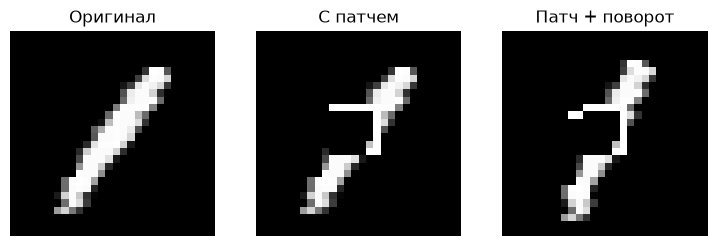

In [3]:

import torchvision.transforms.functional as TF

success = 0; total = 0
for i, (x,y) in enumerate(test_loader):
    if i>=100: break
    x_p = apply_patch(x, patch)
    angle = np.random.uniform(-10,10)
    x_p_rot = TF.rotate(x_p, angle)
    pred = model(x_p_rot).argmax(1).item()
    if pred == target_class.item():
        success += 1
    total += 1
print(f"Доля успешных срабатываний патча (целевой класс {target_class.item()}) с учётом случайного поворота: {success/total:.2%}")

fig, ax = plt.subplots(1,3, figsize=(9,3))
x0,_ = next(iter(test_loader))
ax[0].imshow(x0[0,0], cmap='gray'); ax[0].set_title("Оригинал"); ax[0].axis('off')
ax[1].imshow(apply_patch(x0, patch)[0,0].detach(), cmap='gray'); ax[1].set_title("С патчем"); ax[1].axis('off')
ax[2].imshow(TF.rotate(apply_patch(x0, patch), 10)[0,0].detach(), cmap='gray'); ax[2].set_title("Патч + поворот"); ax[2].axis('off')
plt.savefig('output/notebooks/lec7_patch.png', dpi=120)
plt.show()
